In [1]:
# to load and manipulate the data
import pandas as pd
import numpy as np
import datetime as dt
import re

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Kaggle Dataset**

In [3]:
kaggle_df = pd.read_csv('/content/drive/MyDrive/Project1_RE_Price_Predictor/data/raw/realtor-data.csv')
kaggle_df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN




---


*   Data Overview




In [4]:
kaggle_df.shape

(2226382, 12)

In [5]:
kaggle_df.columns

Index(['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street',
       'city', 'state', 'zip_code', 'house_size', 'prev_sold_date'],
      dtype='object')

In [6]:
kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


In [7]:
kaggle_df.describe().T

,count,mean,std,min,25%,50%,75%,max
brokered_by,2221849.0,5.293989e+04,3.064275e+04,0.0,23861.00,52884.00,79183.00,1.101420e+05
price,2224841.0,5.241955e+05,2.138893e+06,0.0,165000.00,325000.00,550000.00,2.147484e+09
bed,1745065.0,3.275841e+00,1.567274e+00,1.0,3.00,3.00,4.00,4.730000e+02
bath,1714611.0,2.496440e+00,1.652573e+00,1.0,2.00,2.00,3.00,8.300000e+02
acre_lot,1900793.0,1.522303e+01,7.628238e+02,0.0,0.15,0.26,0.98,1.000000e+05
street,2215516.0,1.012325e+06,5.837635e+05,0.0,506312.75,1012765.50,1521173.25,2.001357e+06
zip_code,2226083.0,5.218668e+04,2.895408e+04,0.0,29617.00,48382.00,78070.00,9.999900e+04
house_size,1657898.0,2.714471e+03,8.081635e+05,4.0,1300.00,1760.00,2413.00,1.040400e+09


- Zip code has a minimum of 0 which is invalid because no zip is **00000**.
- Some house sizes have a minimum of 4 sqft and max over a billion with 50%  sitting between **1300 and 2413**.

- Price has a max of **2,147,484,000**, doesnt seem like a real listing.

- Beds and baths both have very high max,which seems also unlikely.

- acre_lot also have  minimum of 0.

In [8]:
kaggle_df.isnull().sum()

,0
brokered_by,4533
status,0
price,1541
bed,481317
bath,511771
acre_lot,325589
street,10866
city,1407
state,8
zip_code,299


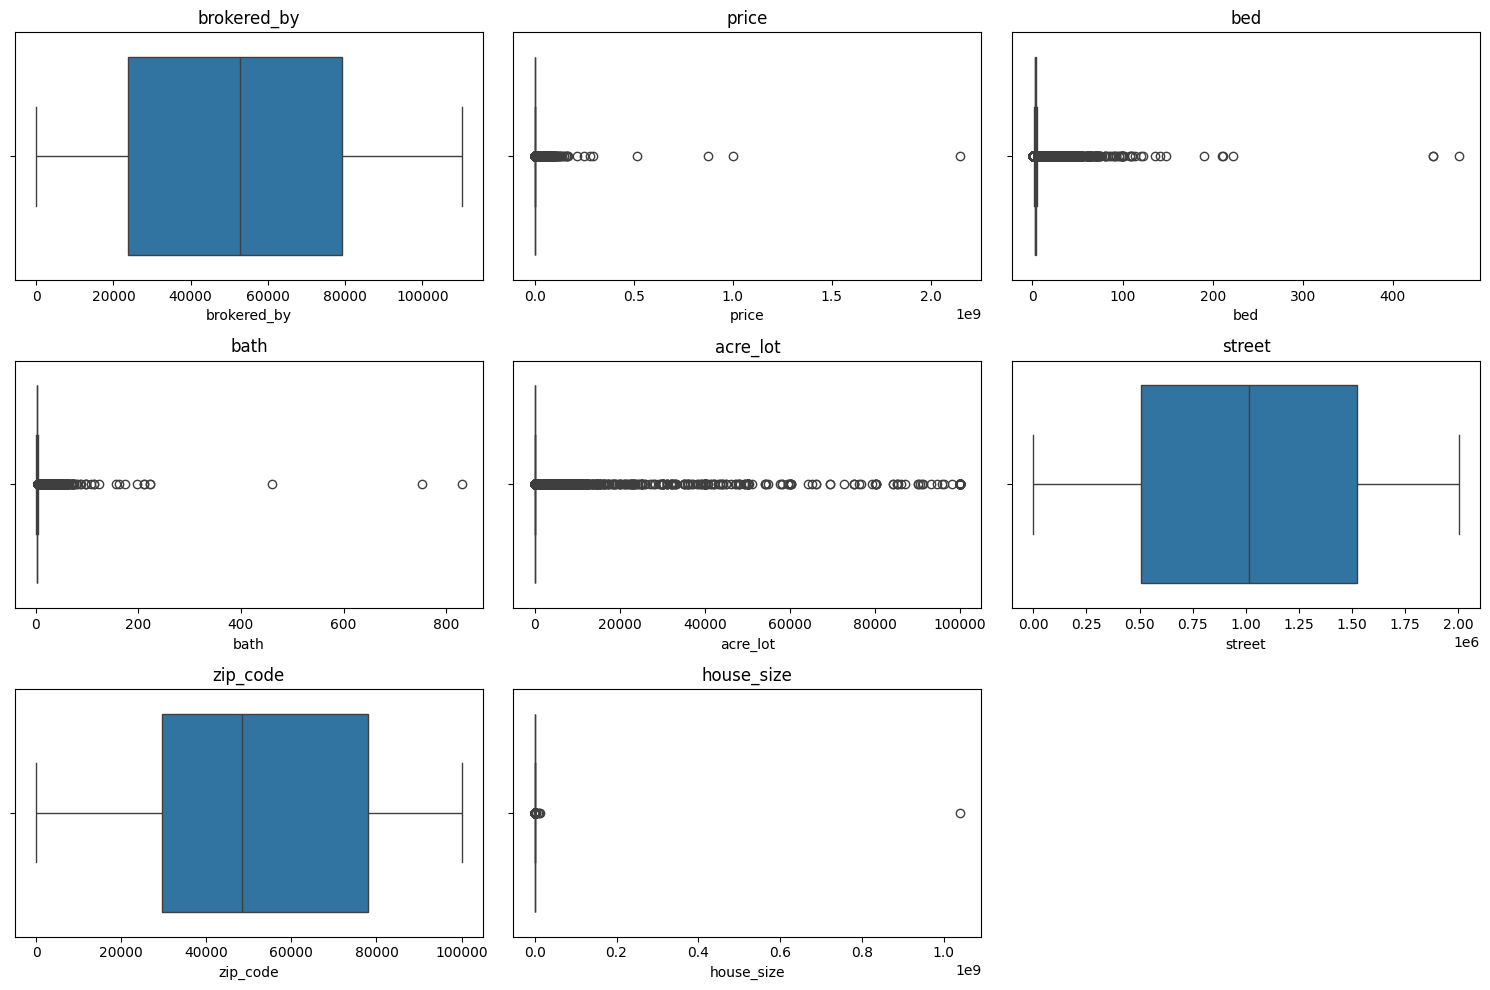

In [9]:
plt.figure(figsize = (15, 10))

features = kaggle_df.select_dtypes(include=['number']).columns.tolist()

# Creating the histograms
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data = kaggle_df, x = feature)
    plt.title(feature)

plt.tight_layout()
plt.show()

In [10]:
missing_percentage = kaggle_df.isnull().sum() / kaggle_df.shape[0] * 100
missing_percentage

,0
brokered_by,0.203604
status,0.000000
price,0.069215
bed,21.618797
bath,22.986666
acre_lot,14.624130
street,0.488056
city,0.063197
state,0.000359
zip_code,0.013430


In [11]:
print(kaggle_df['status'].value_counts(dropna=False))
print()

status
for_sale          1389306
sold               812009
ready_to_build      25067
Name: count, dtype: int64



In [12]:
for col in ['bed', 'bath', 'house_size']:
    print(f"- % missing in '{col}' by status -")
    missing_rate = (
        kaggle_df.assign(is_missing=kaggle_df[col].isna())
        .groupby('status')['is_missing']
        .mean()
        .mul(100)
        .round(1)
        .sort_values(ascending=False)
    )
    print(missing_rate)
    print()

- % missing in 'bed' by status -
status
for_sale          29.6
sold               8.6
ready_to_build     0.0
Name: is_missing, dtype: float64

- % missing in 'bath' by status -
status
ready_to_build    100.0
for_sale           29.4
sold                9.6
Name: is_missing, dtype: float64

- % missing in 'house_size' by status -
status
for_sale          33.5
sold              12.8
ready_to_build     0.0
Name: is_missing, dtype: float64



In [13]:
def clean_kaggle_df(df):
    df = df.copy()

    # standardize column names (no-op here, but safe/reusable across datasets)
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

    start_rows = len(df)

    # --- exact duplicate rows ---
    before = len(df)
    df = df.drop_duplicates()
    print(f"Dropped {before - len(df):,} exact duplicate rows")

    # --- dtype fixes ---
    # zip_code: 0.0 and 99999.0 are both sentinel/placeholder values, not real
    # zips -- 99999 shows up paired with city == "Out Of County", confirming
    # it's a scrape placeholder for unmatched properties, not an actual Alaska zip.
    # pd.to_numeric first guards against zip_code already being a messy string
    # (e.g. "601.0") if this function gets re-run on partially-processed data.
    df['zip_code'] = pd.to_numeric(df['zip_code'], errors='coerce').replace([0, 99999], np.nan)
    df['zip_code'] = df['zip_code'].astype('Int64').astype(str).str.zfill(5)
    df['zip_code'] = df['zip_code'].replace('<NA>', np.nan)

    # prev_sold_date -> real datetime (will NaT anything unparseable)
    df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], errors='coerce')

    # status/city/state -> cleaned strings. "Out Of County" is the same
    # placeholder pattern as zip 99999 -> treat as missing, not a real city.
    df['status'] = df['status'].str.strip().str.lower().astype('category')
    df['city'] = df['city'].str.strip().str.title()
    df.loc[df['city'] == 'Out Of County', 'city'] = np.nan
    df['state'] = df['state'].str.strip().str.title()

    # brokered_by / street are IDs, not magnitudes -> keep as nullable ints, not float.
    # brokered_by min of 0 is left alone (plausible ID, not an error like zip 0 is)
    df['brokered_by'] = df['brokered_by'].astype('Int64')
    df['street'] = df['street'].astype('Int64')

    # --- target column: drop rows with no price, can't train on them ---
    before = len(df)
    df = df.dropna(subset=['price'])
    print(f"Dropped {before - len(df):,} rows with missing price (target)")

    # --- impossible values -> NaN (flagged as missing, not silently dropped) ---
    # price: 0 is invalid; max in the raw data was 2,147,484,000, suspiciously close
    # to the 32-bit signed int ceiling (2,147,483,647) -> looks like an overflow/
    # corruption artifact from the source pipeline, not a real luxury sale. 50M cap
    # generously covers legitimate ultra-luxury listings while dropping the overflow junk.
    df.loc[(df['price'] <= 0) | (df['price'] > 50_000_000), 'price'] = np.nan

    # house_size: raw min was 4 sqft, max was 1.04 billion sqft -- both impossible.
    # Middle 50% sat between 1,300-2,413 sqft, so bounds well outside that are safe to null.
    df.loc[(df['house_size'] < 100) | (df['house_size'] > 50_000), 'house_size'] = np.nan

    # acre_lot: raw min was 0, max was 100,000 acres (156 sq mi) -- both impossible
    # for a residential lot. 640 acres (1 sq mi) is a generous ceiling for rural listings.
    df.loc[(df['acre_lot'] <= 0) | (df['acre_lot'] > 640), 'acre_lot'] = np.nan

    # bed/bath: raw max was 473 beds / 830 baths -- clearly bad rows. 15 is a
    # generous ceiling for even large estate listings.
    df.loc[(df['bed'] <= 0) | (df['bed'] > 15), 'bed'] = np.nan
    df.loc[(df['bath'] <= 0) | (df['bath'] > 15), 'bath'] = np.nan

    # --- missingness flags ---
    # bed/bath/house_size missingness correlates with status (not random -- ready_to_build
    # is 100% missing bath, for_sale runs ~3x the missing rate of sold) rather than being
    # pure noise, so it's signal worth keeping explicit for tree-based models rather than
    # imputing it away. Computed after the outlier-nulling above so newly-nulled invalid
    # values count as missing too.
    for col in ['bed', 'bath', 'house_size']:
        df[f'is_missing_{col}'] = df[col].isna()

    # prev_sold_date: 33% missing, most likely new-construction/never-resold properties
    # rather than a data gap -- a boolean flag is more useful than imputing a date.
    df['has_sold_before'] = df['prev_sold_date'].notna()

    print(f"Final shape: {df.shape} (started at {start_rows:,} rows)")
    return df


kaggle_df = clean_kaggle_df(kaggle_df)

Dropped 0 exact duplicate rows
Dropped 1,541 rows with missing price (target)
Final shape: (2224841, 16) (started at 2,226,382 rows)


In [14]:
kaggle_df.info()
kaggle_df.isnull().sum()
kaggle_df.describe().T

<class 'pandas.core.frame.DataFrame'>
Index: 2224841 entries, 0 to 2226381
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   brokered_by            Int64         
 1   status                 category      
 2   price                  float64       
 3   bed                    float64       
 4   bath                   float64       
 5   acre_lot               float64       
 6   street                 Int64         
 7   city                   object        
 8   state                  object        
 9   zip_code               object        
 10  house_size             float64       
 11  prev_sold_date         datetime64[ns]
 12  is_missing_bed         bool          
 13  is_missing_bath        bool          
 14  is_missing_house_size  bool          
 15  has_sold_before        bool          
dtypes: Int64(2), bool(4), category(1), datetime64[ns](1), float64(5), object(3)
memory usage: 218.5+ MB


,count,mean,min,25%,50%,75%,max,std
brokered_by,2220308.0,52936.913423,0.0,23859.0,52882.0,79183.0,110142.0,30643.570537
price,2224431.0,517505.266711,1.0,165000.0,325000.0,550000.0,50000000.0,1048617.093276
bed,1742617.0,3.255629,1.0,3.0,3.0,4.0,15.0,1.1518
bath,1713064.0,2.483602,1.0,2.0,2.0,3.0,15.0,1.156185
acre_lot,1895039.0,4.187366,0.01,0.15,0.26,0.98,640.0,23.504368
street,2213977.0,1012269.240571,0.0,506293.0,1012692.0,1521063.0,2001357.0,583739.969499
house_size,1656810.0,2033.262881,100.0,1300.0,1760.0,2412.0,50000.0,1297.404742
prev_sold_date,1491584,2017-08-16 15:00:12.627648512,1901-01-01 00:00:00,2016-08-09 00:00:00,2021-12-01 00:00:00,2022-03-04 00:00:00,2026-04-08 00:00:00,NaN


In [15]:
kaggle_df['zip_code'] = pd.to_numeric(kaggle_df['zip_code'], errors='coerce').astype('Int64')
kaggle_df['zip_code'] = kaggle_df['zip_code'].astype(str).str.zfill(5)
kaggle_df['zip_code'] = kaggle_df['zip_code'].replace('<NA>', np.nan)

In [16]:
bool_cols = ['is_missing_bed', 'is_missing_bath', 'is_missing_house_size', 'has_sold_before']
kaggle_df[bool_cols] = kaggle_df[bool_cols].astype(int)

In [17]:
print(kaggle_df['prev_sold_date'].dt.year.value_counts().sort_index().head(10))

prev_sold_date
1901.0    1
1904.0    1
1905.0    1
1906.0    1
1909.0    2
1910.0    1
1926.0    1
1928.0    1
1935.0    1
1939.0    1
Name: count, dtype: int64


In [18]:
kaggle_df.tail()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date,is_missing_bed,is_missing_bath,is_missing_house_size,has_sold_before
2226377,23009,sold,359900.0,4.0,2.0,0.33,353094,Richland,Washington,99354,3600.0,2022-03-25,0,0,0,1
2226378,18208,sold,350000.0,3.0,2.0,0.10,1062149,Richland,Washington,99354,1616.0,2022-03-25,0,0,0,1
2226379,76856,sold,440000.0,6.0,3.0,0.50,405677,Richland,Washington,99354,3200.0,2022-03-24,0,0,0,1
2226380,53618,sold,179900.0,2.0,1.0,0.09,761379,Richland,Washington,99354,933.0,2022-03-24,0,0,0,1
2226381,108243,sold,580000.0,5.0,3.0,0.31,307704,Richland,Washington,99354,3615.0,2022-03-23,0,0,0,1




---





---



### **Redfin dataset**

In [19]:
redfin_df = pd.read_csv('/content/drive/MyDrive/Project1_RE_Price_Predictor/data/raw/redfin_market_tracker_trimmed.csv')
redfin_df.head()

,PERIOD_BEGIN,PERIOD_END,REGION_TYPE,REGION,CITY,STATE,STATE_CODE,PROPERTY_TYPE,MEDIAN_SALE_PRICE,MEDIAN_LIST_PRICE,MEDIAN_PPSF,HOMES_SOLD,INVENTORY,MONTHS_OF_SUPPLY,MEDIAN_DOM,AVG_SALE_TO_LIST,SOLD_ABOVE_LIST,PARENT_METRO_REGION
0,2023-03-01,2023-05-31,zip code,Zip Code: 60616,NaN,Illinois,IL,Townhouse,699900.0,647000.0,321.645221,15.0,29.0,NaN,123.0,0.992194,0.133333,"Chicago, IL"
1,2012-05-01,2012-07-31,zip code,Zip Code: 30295,NaN,Georgia,GA,Single Family Residential,108500.0,180900.0,57.410706,12.0,19.0,NaN,65.5,0.975444,0.166667,"Atlanta, GA"
2,2015-06-01,2015-08-31,zip code,Zip Code: 22437,NaN,Virginia,VA,All Residential,220000.0,405000.0,107.913669,5.0,11.0,NaN,107.0,0.943804,0.000000,"Richmond, VA"
3,2019-08-01,2019-10-31,zip code,Zip Code: 23663,NaN,Virginia,VA,Single Family Residential,142450.0,157448.5,104.887361,50.0,44.0,NaN,43.0,0.982548,0.240000,"Virginia Beach, VA"
4,2013-12-01,2014-02-28,zip code,Zip Code: 43023,NaN,Ohio,OH,All Residential,269000.0,199900.0,107.050731,37.0,81.0,NaN,189.0,0.959374,0.054054,"Columbus, OH"


In [20]:
redfin_df.columns = redfin_df.columns.str.lower()

In [21]:
print(redfin_df.info())
print()
print(redfin_df.isnull().sum())
print()
print(redfin_df.isnull().mean().mul(100).round(1))
print()
print(redfin_df.duplicated().sum())
print()
print(redfin_df['region_type'].value_counts(dropna=False))
print()
print(redfin_df['property_type'].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9725026 entries, 0 to 9725025
Data columns (total 18 columns):
 #   Column               Dtype  
---  ------               -----  
 0   period_begin         object 
 1   period_end           object 
 2   region_type          object 
 3   region               object 
 4   city                 float64
 5   state                object 
 6   state_code           object 
 7   property_type        object 
 8   median_sale_price    float64
 9   median_list_price    float64
 10  median_ppsf          float64
 11  homes_sold           float64
 12  inventory            float64
 13  months_of_supply     float64
 14  median_dom           float64
 15  avg_sale_to_list     float64
 16  sold_above_list      float64
 17  parent_metro_region  object 
dtypes: float64(10), object(8)
memory usage: 1.3+ GB
None

period_begin                 0
period_end                   0
region_type                  0
region                       0
city                   9

In [22]:
def clean_redfin_df(df, property_type_filter='All Residential'):
    df = df.copy()
    df.columns = df.columns.str.lower().str.strip()

    start_rows = len(df)

    # city: 100% missing at zip grain -> dead column, drop.
    # region_type: constant ("zip code" for all 9.7M rows) -> zero info, drop.
    # months_of_supply: 100% missing at zip grain -> Redfin doesn't report this
    # metric below the metro level, drop.
    df = df.drop(columns=['city', 'region_type', 'months_of_supply'])

    # region arrives as "Zip Code: 60616" text -> extract the real 5-digit zip
    df['zip_code'] = df['region'].str.extract(r'(\d{5})')
    df = df.drop(columns=['region'])

    # real dates instead of strings
    df['period_begin'] = pd.to_datetime(df['period_begin'], errors='coerce')
    df['period_end'] = pd.to_datetime(df['period_end'], errors='coerce')

    # exact duplicate rows
    before = len(df)
    df = df.drop_duplicates()
    print(f"Dropped {before - len(df):,} exact duplicate rows")

    # property_type creates up to 5 rows per zip+period (All Residential, Single
    # Family Residential, Condo/Co-op, Townhouse, Multi-Family). Filter down to
    # one to avoid row duplication when this joins onto individual listings later.
    before = len(df)
    df = df[df['property_type'] == property_type_filter].drop(columns=['property_type'])
    print(f"Filtered to property_type == '{property_type_filter}': {before:,} -> {len(df):,} rows")

    print(f"Final shape: {df.shape} (started at {start_rows:,} rows)")
    return df


redfin_df = clean_redfin_df(redfin_df)

Dropped 0 exact duplicate rows
Filtered to property_type == 'All Residential': 9,725,026 -> 3,298,202 rows
Final shape: (3298202, 14) (started at 9,725,026 rows)


In [23]:
redfin_df.tail(10)

,period_begin,period_end,state,state_code,median_sale_price,median_list_price,median_ppsf,homes_sold,inventory,median_dom,avg_sale_to_list,sold_above_list,parent_metro_region,zip_code
9724999,2015-05-01,2015-07-31,Indiana,IN,76950.0,79500.0,54.662172,116.0,222.0,78.5,0.936924,0.051724,"Elkhart, IN",46516
9725001,2025-05-01,2025-07-31,Alabama,AL,378312.0,391000.0,185.568789,135.0,165.0,61.5,0.983528,0.162963,"Daphne, AL",36527
9725002,2023-08-01,2023-10-31,Texas,TX,231000.0,495000.0,138.888889,5.0,5.0,35.0,0.968852,0.200000,"Killeen, TX",76534
9725003,2019-09-01,2019-11-30,Illinois,IL,178750.0,185000.0,113.896363,144.0,194.0,71.0,0.971672,0.138889,"Chicago, IL",60050
9725005,2016-12-01,2017-02-28,Connecticut,CT,664000.0,714500.0,179.408745,42.0,120.0,134.5,0.962199,0.190476,"Bridgeport, CT",06903
9725007,2025-05-01,2025-07-31,Nebraska,NE,81000.0,109000.0,68.760611,3.0,1.0,26.0,0.891762,0.333333,"Norfolk, NE",68768
9725014,2023-06-01,2023-08-31,Missouri,MO,226000.0,257500.0,168.350168,11.0,9.0,27.5,1.051422,0.818182,"St. Louis, MO",63023
9725016,2012-05-01,2012-07-31,California,CA,675000.0,724850.0,355.932203,7.0,10.0,45.0,0.986224,0.285714,"San Francisco, CA",94037
9725024,2020-02-01,2020-04-30,Illinois,IL,35000.0,79900.0,26.515152,1.0,3.0,175.0,0.877193,0.000000,"Springfield, IL",62688
9725025,2021-10-01,2021-12-31,Oregon,OR,495000.0,NaN,217.582418,1.0,1.0,64.0,1.000000,0.000000,"Klamath Falls, OR",97639


In [24]:
redfin_df.columns

Index(['period_begin', 'period_end', 'state', 'state_code',
       'median_sale_price', 'median_list_price', 'median_ppsf', 'homes_sold',
       'inventory', 'median_dom', 'avg_sale_to_list', 'sold_above_list',
       'parent_metro_region', 'zip_code'],
      dtype='object')

In [25]:
redfin_df.isnull().sum()

,0
period_begin,0
period_end,0
state,0
state_code,0
median_sale_price,5583
median_list_price,152046
median_ppsf,19933
homes_sold,5542
inventory,209759
median_dom,25670


In [26]:
low_volume = redfin_df[redfin_df['homes_sold'] <= 3]
print(f"% missing median_list_price, homes_sold<=3: {low_volume['median_list_price'].isna().mean()*100:.1f}%")
print(f"% missing median_list_price, overall: {redfin_df['median_list_price'].isna().mean()*100:.1f}%")

% missing median_list_price, homes_sold<=3: 20.5%
% missing median_list_price, overall: 4.6%


### **Zillow dataset**

In [27]:
zillow_df_inventory = pd.read_csv('/content/drive/MyDrive/Project1_RE_Price_Predictor/data/raw/zillow_inventory.csv')
zillow_df_inventory.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2018-03-31,...,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,642.0,...,698.0,661.0,616.0,573.0,538.0,534.0,570.0,614.0,659.0,704.0
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,482.0,...,215.0,207.0,209.0,208.0,217.0,217.0,222.0,227.0,244.0,265.0
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,276.0,...,490.0,496.0,492.0,480.0,466.0,458.0,462.0,474.0,505.0,546.0
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,89.0,...,105.0,106.0,104.0,102.0,93.0,90.0,89.0,94.0,96.0,98.0
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,280.0,...,422.0,421.0,411.0,394.0,383.0,381.0,386.0,390.0,388.0,388.0


In [28]:
zillow_df_inventory.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'City', 'Metro', 'CountyName', '2018-03-31',
       ...
       '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31',
       '2026-02-28', '2026-03-31', '2026-04-30', '2026-05-31', '2026-06-30'],
      dtype='object', length=109)

In [29]:
print(zillow_df_inventory.info())
print()
print(zillow_df_inventory.isnull().sum())
print()
print(zillow_df_inventory.isnull().mean().mul(100).round(1))
print()
print(zillow_df_inventory.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21240 entries, 0 to 21239
Columns: 109 entries, RegionID to 2026-06-30
dtypes: float64(100), int64(3), object(6)
memory usage: 17.7+ MB
None

RegionID         0
SizeRank         0
RegionName       0
RegionType       0
StateName        0
              ... 
2026-02-28    2821
2026-03-31    2248
2026-04-30    1569
2026-05-31     828
2026-06-30      20
Length: 109, dtype: int64

RegionID       0.0
SizeRank       0.0
RegionName     0.0
RegionType     0.0
StateName      0.0
              ... 
2026-02-28    13.3
2026-03-31    10.6
2026-04-30     7.4
2026-05-31     3.9
2026-06-30     0.1
Length: 109, dtype: float64

0


In [30]:
zillow_df_inventory.describe().T

,count,mean,std,min,25%,50%,75%,max
RegionID,21240.0,81329.870245,32014.425613,58196.0,69142.75,79028.5,90473.25,845914.0
SizeRank,21240.0,11440.209228,7348.648489,1.0,5372.75,10771.0,16551.25,39994.0
RegionName,21240.0,49172.404002,28398.790203,1001.0,26629.25,48109.5,74337.25,99950.0
2018-03-31,13714.0,95.020709,96.890771,3.0,37.00,66.0,121.00,2239.0
2018-04-30,13724.0,100.311061,100.419773,4.0,39.00,71.0,128.00,2221.0
...,...,...,...,...,...,...,...,...
2026-02-28,18419.0,59.092187,82.939075,2.0,13.00,31.0,72.00,1984.0
2026-03-31,18992.0,59.590512,85.150916,2.0,12.00,31.0,72.00,1984.0
2026-04-30,19671.0,60.885974,86.751417,2.0,12.00,31.0,75.00,1962.0
2026-05-31,20412.0,62.773124,88.185933,2.0,12.00,32.0,79.00,1938.0


In [31]:
pd.set_option('display.max_rows', None)
print(zillow_df_inventory.isnull().mean().mul(100).round(1))
print()
print(zillow_df_inventory['RegionType'].value_counts(dropna=False))
print(zillow_df_inventory.duplicated().sum())

RegionID       0.0
SizeRank       0.0
RegionName     0.0
RegionType     0.0
StateName      0.0
State          0.0
City           0.0
Metro         15.4
CountyName     0.0
2018-03-31    35.4
2018-04-30    35.4
2018-05-31    35.4
2018-06-30    35.4
2018-07-31    35.3
2018-08-31    35.3
2018-09-30    35.3
2018-10-31    35.3
2018-11-30    35.3
2018-12-31    35.3
2019-01-31    35.3
2019-02-28    35.3
2019-03-31    35.3
2019-04-30    35.3
2019-05-31    35.3
2019-06-30    35.3
2019-07-31    35.3
2019-08-31    35.3
2019-09-30    35.2
2019-10-31    35.2
2019-11-30    35.2
2019-12-31    35.2
2020-01-31    35.2
2020-02-29    35.2
2020-03-31    35.2
2020-04-30    35.2
2020-05-31    35.2
2020-06-30    35.5
2020-07-31    35.2
2020-08-31    35.1
2020-09-30    35.1
2020-10-31    35.1
2020-11-30    35.1
2020-12-31    35.1
2021-01-31    35.0
2021-02-28    34.8
2021-03-31    34.6
2021-04-30    34.3
2021-05-31    34.3
2021-06-30    33.9
2021-07-31    33.8
2021-08-31    33.7
2021-09-30    33.6
2021-10-31  

In [32]:
zillow_df_inventory[['RegionID', 'RegionName', 'State', 'City', 'Metro', 'CountyName']].head()

,RegionID,RegionName,State,City,Metro,CountyName
0,91982,77494,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County
1,61148,8701,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County
2,91940,77449,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County
3,62080,11368,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County
4,91733,77084,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County




---





---



In [33]:
zillow_df_zhvi = pd.read_csv('/content/drive/MyDrive/Project1_RE_Price_Predictor/data/raw/zillow_zhvi.csv')
zillow_df_zhvi.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,213111.592027,...,497526.794912,498286.784580,499376.480416,499989.065082,499586.486230,498143.244655,496495.816742,494706.840288,492779.651430,490766.064686
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,114699.144093,...,554599.792526,559584.518384,565617.054803,571979.469085,576533.957551,580327.060524,583315.914997,586024.988152,588876.111080,591550.140815
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,105668.111801,...,277376.323874,276622.912998,275975.647545,275630.375640,275070.980979,274662.435149,274262.433819,273968.701005,273160.259306,272004.456555
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,169804.913793,...,526713.648295,527718.930982,529596.981021,532233.300326,536910.151303,541753.480648,546530.631030,548533.451192,549519.050190,549323.819519
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,105443.465235,...,273785.535035,272912.171689,272162.867266,271810.185959,271292.379016,270801.342303,270312.027624,269881.136681,269008.656228,267820.730413


In [34]:
zillow_df_zhvi.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'City', 'Metro', 'CountyName', '2000-01-31',
       ...
       '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31',
       '2026-02-28', '2026-03-31', '2026-04-30', '2026-05-31', '2026-06-30'],
      dtype='object', length=327)

In [35]:
print(zillow_df_zhvi.info())
print()
print(zillow_df_zhvi.isnull().sum())
print()
print(zillow_df_zhvi.isnull().mean().mul(100).round(1))
print()
print(zillow_df_zhvi.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26274 entries, 0 to 26273
Columns: 327 entries, RegionID to 2026-06-30
dtypes: float64(318), int64(3), object(6)
memory usage: 65.5+ MB
None

RegionID          0
SizeRank          0
RegionName        0
RegionType        0
StateName         0
State             0
City              7
Metro          4714
CountyName        0
2000-01-31    13382
2000-02-29    13316
2000-03-31    13302
2000-04-30    13283
2000-05-31    13220
2000-06-30    13209
2000-07-31    13193
2000-08-31    13168
2000-09-30    13153
2000-10-31    13140
2000-11-30    13120
2000-12-31    13104
2001-01-31    12974
2001-02-28    12937
2001-03-31    12896
2001-04-30    12861
2001-05-31    12838
2001-06-30    12828
2001-07-31    12816
2001-08-31    12790
2001-09-30    12738
2001-10-31    12706
2001-11-30    12678
2001-12-31    12656
2002-01-31    12610
2002-02-28    12591
2002-03-31    12560
2002-04-30    12431
2002-05-31    12410
2002-06-30    12322
2002-07-31    12310
2002-08-

In [36]:
def clean_zillow_wide_df(df, value_name):
    """Cleans a Zillow zip-level wide file (RegionName + one column per date)
    into long format: one row per zip per month."""
    df = df.copy()
    df.columns = df.columns.str.lower()

    # RegionName is a bare number with leading zeros stripped (e.g. NJ zip
    # 8701 instead of 08701) -- same fix as kaggle_df's zip_code.
    df['zip_code'] = df['regionname'].astype(str).str.zfill(5)

    id_vars = [c for c in ['zip_code', 'state', 'statename', 'city', 'metro', 'countyname'] if c in df.columns]
    date_cols = [c for c in df.columns if c[:4].isdigit()]  # e.g. '2018-03-31'

    long_df = df.melt(id_vars=id_vars, value_vars=date_cols, var_name='date', value_name=value_name)
    long_df['date'] = pd.to_datetime(long_df['date'], errors='coerce')

    before = len(long_df)
    long_df = long_df.drop_duplicates()
    print(f"Dropped {before - long_df.shape[0]:,} duplicate rows")

    print(f"Final shape: {long_df.shape} (from {df.shape[0]:,} zips x {len(date_cols)} months)")
    return long_df

In [37]:
zillow_df_inventory = clean_zillow_wide_df(zillow_df_inventory, value_name='for_sale_inventory')

Dropped 0 duplicate rows
Final shape: (2124000, 8) (from 21,240 zips x 100 months)


In [38]:
zillow_df_zhvi = clean_zillow_wide_df(zillow_df_zhvi, value_name='zhvi')

Dropped 0 duplicate rows
Final shape: (8355132, 8) (from 26,274 zips x 318 months)


In [39]:
zillow_df_inventory.head()

,zip_code,state,statename,city,metro,countyname,date,for_sale_inventory
0,77494,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,2018-03-31,642.0
1,08701,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,2018-03-31,482.0
2,77449,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,2018-03-31,276.0
3,11368,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2018-03-31,89.0
4,77084,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,2018-03-31,280.0


In [40]:
zillow_df_zhvi.head()

,zip_code,state,statename,city,metro,countyname,date,zhvi
0,77494,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,2000-01-31,213111.592027
1,08701,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,2000-01-31,114699.144093
2,77449,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,105668.111801
3,11368,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,169804.913793
4,77084,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,105443.465235


In [41]:
zillow_df_inventory.isnull().sum()

,0
zip_code,0
state,0
statename,0
city,800
metro,326500
countyname,0
date,0
for_sale_inventory,612175


In [42]:
zillow_df_zhvi.isnull().sum()

,0
zip_code,0
state,0
statename,0
city,2226
metro,1499052
countyname,0
date,0
zhvi,1924471


### **Realtor dataset**

In [43]:
realtor_df = pd.read_csv('/content/drive/MyDrive/Project1_RE_Price_Predictor/data/raw/realtor_zip_inventory.csv')
realtor_df.head()

,month_date_yyyymm,postal_code,zip_name,median_listing_price,median_listing_price_mm,median_listing_price_yy,active_listing_count,active_listing_count_mm,active_listing_count_yy,median_days_on_market,...,average_listing_price,average_listing_price_mm,average_listing_price_yy,total_listing_count,total_listing_count_mm,total_listing_count_yy,pending_ratio,pending_ratio_mm,pending_ratio_yy,quality_flag
0,202606,83323,"declo, id",512500.0,0.1946,-0.0867,3,0.0000,-0.2500,60.0,...,495833.0,0.0787,-0.1994,4,0.0000,-0.2000,0.3333,0.0000,0.0833,0.0
1,202606,47615,"grandview, in",161150.0,-0.0077,-0.4100,5,0.1250,3.5000,77.0,...,176133.0,-0.0952,-0.3551,6,0.1000,0.8333,0.2222,-0.0278,-1.7778,1.0
2,202606,76837,"eden, tx",125000.0,0.0870,0.2148,7,0.0833,-0.2778,58.0,...,134821.0,0.1792,-0.4958,9,0.2857,0.0000,0.3846,0.2179,NaN,0.0
3,202606,74054,"osage, ok",124450.0,-0.0600,-0.2806,2,0.0000,1.0000,80.0,...,124450.0,-0.0600,-0.2806,2,0.0000,1.0000,0.5000,0.0000,NaN,1.0
4,202606,46171,"reelsville, in",387400.0,0.2110,-0.1596,4,0.3333,0.1429,41.0,...,410767.0,0.1705,-0.1910,7,0.0833,0.0000,0.7500,-0.2500,-0.1071,1.0


In [44]:
realtor_df.columns.str.lower()

Index(['month_date_yyyymm', 'postal_code', 'zip_name', 'median_listing_price',
       'median_listing_price_mm', 'median_listing_price_yy',
       'active_listing_count', 'active_listing_count_mm',
       'active_listing_count_yy', 'median_days_on_market',
       'median_days_on_market_mm', 'median_days_on_market_yy',
       'new_listing_count', 'new_listing_count_mm', 'new_listing_count_yy',
       'price_increased_count', 'price_increased_count_mm',
       'price_increased_count_yy', 'price_increased_share',
       'price_increased_share_mm', 'price_increased_share_yy',
       'price_reduced_count', 'price_reduced_count_mm',
       'price_reduced_count_yy', 'price_reduced_share',
       'price_reduced_share_mm', 'price_reduced_share_yy',
       'pending_listing_count', 'pending_listing_count_mm',
       'pending_listing_count_yy', 'median_listing_price_per_square_foot',
       'median_listing_price_per_square_foot_mm',
       'median_listing_price_per_square_foot_yy', 'median_square_

In [45]:
print(realtor_df.info())
print()
print(realtor_df.isnull().sum())
print()
print(realtor_df.isnull().mean().mul(100).round(1))
print()
print(realtor_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3394470 entries, 0 to 3394469
Data columns (total 46 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   month_date_yyyymm                        int64  
 1   postal_code                              int64  
 2   zip_name                                 object 
 3   median_listing_price                     float64
 4   median_listing_price_mm                  float64
 5   median_listing_price_yy                  float64
 6   active_listing_count                     int64  
 7   active_listing_count_mm                  float64
 8   active_listing_count_yy                  float64
 9   median_days_on_market                    float64
 10  median_days_on_market_mm                 float64
 11  median_days_on_market_yy                 float64
 12  new_listing_count                        int64  
 13  new_listing_count_mm                     float64
 14  new_listing_count_

In [46]:
realtor_df['quality_flag'].value_counts(dropna=False)

,count
quality_flag,
1.0,1666122
0.0,1379803
NaN,348545


In [47]:
print(realtor_df.groupby('quality_flag')['active_listing_count'].describe())
print()
print(realtor_df.groupby('quality_flag')[['median_listing_price', 'median_days_on_market']].apply(lambda g: g.isna().mean() * 100))

                  count       mean        std  min  25%   50%   75%     max
quality_flag                                                               
0.0           1379803.0  48.536782  73.841939  0.0  6.0  25.0  62.0  2646.0
1.0           1666122.0  16.403418  34.143106  0.0  2.0   6.0  16.0  1796.0

              median_listing_price  median_days_on_market
quality_flag                                             
0.0                       0.131323               0.843019
1.0                       0.076165               0.670659


In [48]:
def clean_realtor_df(df):
    df = df.copy()
    df.columns = df.columns.str.lower().str.strip()

    start_rows = len(df)

    # postal_code loses leading zeros as int64, same fix as everywhere else
    df['zip_code'] = df['postal_code'].astype(str).str.zfill(5)
    df = df.drop(columns=['postal_code'])

    # month_date_yyyymm (e.g. 202301) -> real datetime
    df['date'] = pd.to_datetime(df['month_date_yyyymm'], format='%Y%m', errors='coerce')
    df = df.drop(columns=['month_date_yyyymm'])

    # drop all _mm/_yy derived delta columns -- consistent with how redfin_df
    # was trimmed (no MoM/YoY variants kept there either). Some of these
    # (price_increased_count_mm/yy) are 91-94% missing and effectively
    # unusable anyway, likely divide-by-zero when the prior period's count was 0.
    delta_cols = [c for c in df.columns if c.endswith('_mm') or c.endswith('_yy')]
    df = df.drop(columns=delta_cols)
    print(f"Dropped {len(delta_cols)} MoM/YoY delta columns")

    before = len(df)
    df = df.drop_duplicates()
    print(f"Dropped {before - len(df):,} exact duplicate rows")

    print(f"Final shape: {df.shape} (started at {start_rows:,} rows)")
    return df


realtor_df = clean_realtor_df(realtor_df)

Dropped 28 MoM/YoY delta columns
Dropped 239 exact duplicate rows
Final shape: (3394231, 18) (started at 3,394,470 rows)


In [49]:
realtor_df.head()

,zip_name,median_listing_price,active_listing_count,median_days_on_market,new_listing_count,price_increased_count,price_increased_share,price_reduced_count,price_reduced_share,pending_listing_count,median_listing_price_per_square_foot,median_square_feet,average_listing_price,total_listing_count,pending_ratio,quality_flag,zip_code,date
0,"declo, id",512500.0,3,60.0,0,0,0.0,0.0,0.0,1.0,226.0,2299.0,495833.0,4,0.3333,0.0,83323,2026-06-01
1,"grandview, in",161150.0,5,77.0,0,0,0.0,2.0,0.2,1.0,133.0,1334.0,176133.0,6,0.2222,1.0,47615,2026-06-01
2,"eden, tx",125000.0,7,58.0,4,0,0.0,0.0,0.0,3.0,117.0,1139.0,134821.0,9,0.3846,0.0,76837,2026-06-01
3,"osage, ok",124450.0,2,80.0,0,0,0.0,2.0,1.0,1.0,97.0,1292.0,124450.0,2,0.5000,1.0,74054,2026-06-01
4,"reelsville, in",387400.0,4,41.0,2,0,0.0,0.0,0.0,3.0,184.0,2032.0,410767.0,7,0.7500,1.0,46171,2026-06-01


In [50]:
# Drop columns that overlap with realtor_df's listing-side metrics, which have meaningfully better coverage

redfin_df = redfin_df.drop(columns=['median_list_price', 'inventory', 'median_dom'])

In [51]:
kaggle_df = kaggle_df.sort_values(['zip_code', 'prev_sold_date'])

redfin_df = redfin_df.rename(columns={'period_begin': 'date'}).sort_values(['zip_code', 'date'])
realtor_df = realtor_df.sort_values(['zip_code', 'date'])
zillow_df_zhvi = zillow_df_zhvi.sort_values(['zip_code', 'date'])
zillow_df_inventory = zillow_df_inventory.sort_values(['zip_code', 'date'])

In [58]:
import gc
import pandas as pd

# --- prep: consistent date column naming, sorted for merge_asof ---
kaggle_df = kaggle_df.sort_values('prev_sold_date')
redfin_df = redfin_df.rename(columns={'period_begin': 'date'}).sort_values('date')
realtor_df = realtor_df.sort_values('date')
zillow_df_zhvi = zillow_df_zhvi.sort_values('date')
zillow_df_inventory = zillow_df_inventory.sort_values('date')

redfin_cols = ['median_sale_price', 'median_ppsf', 'homes_sold', 'avg_sale_to_list',
               'sold_above_list', 'parent_metro_region']
realtor_cols = ['median_listing_price', 'active_listing_count', 'median_days_on_market',
                'new_listing_count', 'price_increased_count', 'price_increased_share',
                'price_reduced_count', 'price_reduced_share', 'pending_listing_count',
                'median_listing_price_per_square_foot', 'median_square_feet',
                'average_listing_price', 'total_listing_count', 'pending_ratio', 'quality_flag']
zhvi_cols = ['zhvi']
inv_cols = ['for_sale_inventory']

# downcast float64 -> float32 on the right-side value columns to shrink the
# memory footprint of the tables merge_asof holds for the whole run
for df_, cols in [(redfin_df, redfin_cols), (realtor_df, realtor_cols),
                   (zillow_df_zhvi, zhvi_cols), (zillow_df_inventory, inv_cols)]:
    for col in cols:
        if df_[col].dtype == 'float64':
            df_[col] = df_[col].astype('float32')

# rows with no prev_sold_date can't be date-matched -- handled separately below,
# no join needed for them at all
has_date = kaggle_df[kaggle_df['prev_sold_date'].notna()].copy()
no_date = kaggle_df[kaggle_df['prev_sold_date'].isna()].copy()


def asof_join(left, right, right_cols, tolerance_days=45):
    return pd.merge_asof(
        left,
        right[['zip_code', 'date'] + right_cols],
        left_on='prev_sold_date',
        right_on='date',
        by='zip_code',
        direction='nearest',
        tolerance=pd.Timedelta(days=tolerance_days),
    ).drop(columns=['date'])


dest = '/content/drive/MyDrive/Project1_RE_Price_Predictor/data/processed/'
out_path = dest + 'master_dataset.csv'

# process has_date in batches so only one chunk's worth of merged columns
# exists in memory at a time, instead of building one giant 2.2M-row frame
chunk_size = 200_000
n_chunks = (len(has_date) // chunk_size) + 1
first_write = True
rows_written = 0
failed_chunks = []

for i in range(n_chunks):
    start = i * chunk_size
    end = start + chunk_size
    chunk = has_date.iloc[start:end].copy()
    if chunk.empty:
        continue

    try:
        chunk = asof_join(chunk, redfin_df, redfin_cols)
        chunk = asof_join(chunk, realtor_df, realtor_cols)
        chunk = asof_join(chunk, zillow_df_zhvi, zhvi_cols)
        chunk = asof_join(chunk, zillow_df_inventory, inv_cols)
    except Exception as e:
        # don't let one chunk's failure silently vanish -- record it and stop,
        # rather than continuing on to write a dataset that's quietly short rows
        print(f"CHUNK {i + 1}/{n_chunks} FAILED: {e}")
        failed_chunks.append(i + 1)
        raise

    chunk.to_csv(out_path, mode='w' if first_write else 'a', header=first_write, index=False)
    first_write = False
    rows_written += len(chunk)

    print(f"Chunk {i + 1}/{n_chunks} done ({len(chunk):,} rows) -- running total: {rows_written:,}")
    del chunk
    gc.collect()

# verify every has_date row actually made it to disk before moving on --
# this is the check that would have caught the silently-dropped chunk last time
assert rows_written == len(has_date), (
    f"Row count mismatch after chunked writes: wrote {rows_written:,}, "
    f"expected {len(has_date):,}. A chunk was lost -- do not proceed with the "
    f"no_date append until this is resolved."
)
print(f"\nVerified: all {rows_written:,} has_date rows written successfully.")

# no_date rows never had a join to do -- just attach NaN market-context columns
# and append them once, no chunking needed since there's no merge happening
for col in redfin_cols + realtor_cols + zhvi_cols + inv_cols:
    no_date[col] = pd.NA

no_date.to_csv(out_path, mode='a', header=False, index=False)

total_rows = rows_written + len(no_date)
print(f"\nSaved to {out_path}")
print(f"Rows with prev_sold_date (date-matched): {rows_written:,}")
print(f"Rows without prev_sold_date (NaN market context): {len(no_date):,}")
print(f"Total rows: {total_rows:,}")

# final sanity check against the source
assert total_rows == len(kaggle_df), (
    f"Total row mismatch: master file has {total_rows:,} rows, "
    f"kaggle_df has {len(kaggle_df):,} rows."
)
print("Verified: total row count matches kaggle_df.")

Chunk 1/8 done (200,000 rows) -- running total: 200,000
Chunk 2/8 done (200,000 rows) -- running total: 400,000
Chunk 3/8 done (200,000 rows) -- running total: 600,000
Chunk 4/8 done (200,000 rows) -- running total: 800,000
Chunk 5/8 done (200,000 rows) -- running total: 1,000,000
Chunk 6/8 done (200,000 rows) -- running total: 1,200,000
Chunk 7/8 done (200,000 rows) -- running total: 1,400,000
Chunk 8/8 done (91,584 rows) -- running total: 1,491,584

Verified: all 1,491,584 has_date rows written successfully.

Saved to /content/drive/MyDrive/Project1_RE_Price_Predictor/data/processed/master_dataset.csv
Rows with prev_sold_date (date-matched): 1,491,584
Rows without prev_sold_date (NaN market context): 733,257
Total rows: 2,224,841
Verified: total row count matches kaggle_df.


In [53]:
master_dataset__df = pd.read_csv('/content/drive/MyDrive/Project1_RE_Price_Predictor/data/processed/master_dataset.csv')
master_dataset__df.tail()

/tmp/ipykernel_41556/2336618695.py:1: DtypeWarning: Columns (9,11,21) have mixed types. Specify dtype option on import or set low_memory=False.
  master_dataset__df = pd.read_csv('/content/drive/MyDrive/Project1_RE_Price_Predictor/data/processed/master_dataset.csv')


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,...,price_reduced_share,pending_listing_count,median_listing_price_per_square_foot,median_square_feet,average_listing_price,total_listing_count,pending_ratio,quality_flag,zhvi,for_sale_inventory
2024497,5274.0,for_sale,20000.0,NaN,NaN,0.11,1843274.0,Wrangell,Alaska,99929,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024498,5274.0,for_sale,65000.0,NaN,NaN,0.22,1773703.0,Wrangell,Alaska,99929,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024499,5274.0,for_sale,75000.0,NaN,NaN,0.24,1773701.0,Wrangell,Alaska,99929,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024500,76577.0,for_sale,149000.0,NaN,1.0,4.52,1904148.0,Naukati Bay,Alaska,99950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024501,16064.0,for_sale,585000.0,6.0,3.0,0.64,1905096.0,Port Protection,Alaska,99950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
 master_dataset__df.isnull().sum()

,0
brokered_by,3998
status,0
price,405
bed,464934
bath,492614
acre_lot,303425
street,10284
city,1383
state,8
zip_code,0


master_dataset_df = pd.read_csv(
    '/content/drive/MyDrive/Project1_RE_Price_Predictor/data/processed/master_dataset.csv',
    dtype={'zip_code': str},
    parse_dates=['prev_sold_date'],
)
master_dataset_df['zip_code'] = master_dataset_df['zip_code'].str.zfill(5)
master_dataset_df.head()

In [55]:
print(kaggle_df['zip_code'].dtype, realtor_df['zip_code'].dtype)
print(kaggle_df['zip_code'].head(10).tolist())
print(realtor_df['zip_code'].head(10).tolist())

object object
['01238', '43314', '73072', '80234', '15419', '33908', '01238', '29581', '17552', '16353']
['42027', '36265', '46614', '60168', '83203', '83204', '95944', '20637', '60169', '36264']


In [56]:
print(realtor_df['date'].dtype)
print(realtor_df['date'].isnull().sum())

datetime64[ns]
0


In [57]:
print(realtor_df['date'].min(), realtor_df['date'].max())
print(realtor_df['date'].nunique())
print(realtor_df['date'].value_counts())

2016-07-01 00:00:00 2026-06-01 00:00:00
120
date
2016-07-01    29386
2017-09-01    29328
2017-07-01    29306
2018-09-01    29306
2016-08-01    29277
2016-10-01    29274
2016-09-01    29229
2017-08-01    29208
2018-08-01    29182
2018-06-01    29176
2019-06-01    29175
2019-07-01    29163
2018-10-01    29162
2017-10-01    29161
2019-11-01    29116
2018-07-01    29087
2017-11-01    29056
2018-11-01    29047
2017-06-01    29047
2016-11-01    29046
2019-10-01    29028
2017-04-01    28999
2025-08-01    28996
2017-12-01    28989
2019-05-01    28978
2018-12-01    28978
2016-12-01    28966
2018-05-01    28950
2017-05-01    28933
2018-03-01    28917
2025-11-01    28889
2018-04-01    28843
2017-03-01    28840
2026-05-01    28803
2025-10-01    28786
2017-02-01    28780
2025-09-01    28778
2017-01-01    28768
2019-01-01    28763
2020-02-01    28745
2026-06-01    28745
2018-01-01    28737
2019-12-01    28728
2018-02-01    28726
2019-04-01    28699
2025-07-01    28666
2019-02-01    28647
2020-01-01 